In [29]:
from dotenv import load_dotenv
load_dotenv()

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

# Compton y calculation
from astropy.constants import k_B, m_p, c, sigma_T, m_e
from astropy import units as u

from astropy.coordinates import SkyCoord
import astropy.units as u

import utils as ut

# latex font
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=22)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
def calc_y_and_err(tau, tau_err, Te, Te_err):
    Te = Te * u.keV
    Te_err = Te_err * u.keV
    Te_K = (Te / k_B).to(u.K)    
    Te_err_K = (Te_err / k_B).to(u.K)

    y = tau * k_B * Te_K / (m_e * c**2).to(u.J)
    yerr = y * np.sqrt((tau_err / tau)**2 + (Te_err_K / Te_K)**2)

    return y.value, yerr.value

def get_y_vector(samples, idx_tau, idx_Te):
    Te = samples[:, idx_Te] * u.keV
    tau = samples[:, idx_tau]
    Te_K = (Te / k_B).to(u.K)
    y = tau * k_B * Te_K / (m_e * c**2).to(u.J)
    return y.value

def calc_mean_and_std(samples, idx):
    data = samples[:, idx]

    mcmc_run = np.percentile(data, [16, 50, 84])
    err = .5 * (mcmc_run[2] - mcmc_run[0])
    
    # Calculate bin width using Freedman-Diaconis rule
    n = len(data)
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    bin_width = 2 * iqr * n**(-1/3)

    # Calculate number of bins using bin width
    num_bins = int((np.max(data) - np.min(data)) / bin_width)

    # Create histogram
    hist, bin_edges = np.histogram(data, bins=num_bins, density=True)

    # Find bin with maximum value (estimate of mode)
    mode_bin = np.argmax(hist)
    mode_value = 0.5 * (bin_edges[mode_bin] + bin_edges[mode_bin + 1])

    mean = mode_value
    std = err
    return mean, std

In [15]:
case50 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case50/chain.h5"
case57 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case57/chain.h5"
case58 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case58/chain.h5"
case59 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case59/chain.h5"
case60 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case60/chain.h5"
case61 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case61/chain.h5"

burnin = 10000
thin = 1

samples_case50 = emcee.backends.HDFBackend(case50).get_chain(discard=burnin, flat=True, thin=thin)
samples_case57 = emcee.backends.HDFBackend(case57).get_chain(discard=burnin, flat=True, thin=thin)
samples_case58 = emcee.backends.HDFBackend(case58).get_chain(discard=burnin, flat=True, thin=thin)
samples_case59 = emcee.backends.HDFBackend(case59).get_chain(discard=burnin, flat=True, thin=thin)
samples_case60 = emcee.backends.HDFBackend(case60).get_chain(discard=burnin, flat=True, thin=thin)
samples_case61 = emcee.backends.HDFBackend(case61).get_chain(discard=burnin, flat=True, thin=thin)

In [16]:
# indices for the chain parameters
param_indices = {
    'ra_a401': 0,
    'dec_a401': 1,
    'beta_a401': 2,
    'rc_a401': 3,
    'R_a401': 4,
    'theta_a401': 5,
    'tau_a401': 6,
    'Te_a401': 7,
    'AD_a401': 8,

    'ra_a399': 9,
    'dec_a399': 10,
    'beta_a399': 11,
    'rc_a399': 12,
    'R_a399': 13,
    'theta_a399': 14,
    'tau_a399': 15,
    'Te_a399': 16,
    'AD_a399': 17,

    'fil_ra': 18,
    'fil_dec': 19,
    'fil_l0': 20,
    'fil_w0': 21,
    'tau_fil': 22,
    'Te_fil': 23,
    'fil_AD': 24,
    'fil_vavg': 25
}

case_labels = ["Temperature: X-ray", 
               r"5\% higher than X-ray", 
               r"10\% higher than X-ray", 
               r"15\% higher than X-ray", 
               r"20\% higher than X-ray", 
               r"25\% higher than X-ray",
]

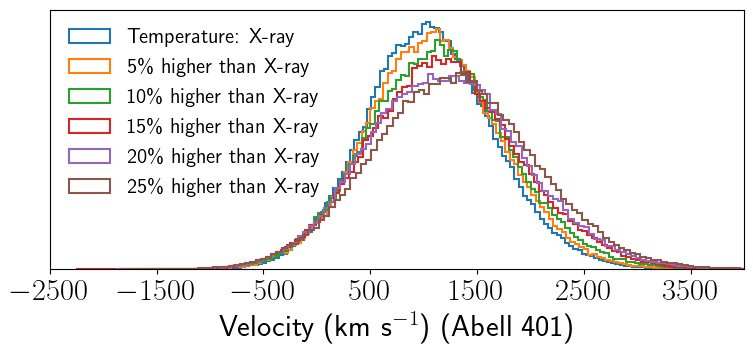

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(samples_case50[:, 9] * 1, bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=1.5)
plt.hist(samples_case57[:, 9] * 1, bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=1.5)
plt.hist(samples_case58[:, 9] * 1, bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=1.5)
plt.hist(samples_case59[:, 9] * 1, bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=1.5)
plt.hist(samples_case60[:, 9] * 1, bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=1.5)
plt.hist(samples_case61[:, 9] * 1, bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=1.5)

plt.xlabel('Velocity (km s$^{-1}$) (Abell 401)')
plt.legend(fontsize=15, frameon=False, loc="upper left")
plt.gca().set_yticks([])
# plt.title("Velocity vs temperature for individual velocity fits (Abell 401)", fontsize=20)
plt.xticks(np.arange(-2500, 4001, 1000))
plt.xlim(-2500, 4000)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a401_sep13.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

In [14]:
samples_case61[:, 9]

array([], dtype=float64)